# Atmospheric Energy Budget
Below I check if I can recreate the atmospheric energy budget.

In [52]:
import copy
import sys
import os
import inspect
from matplotlib.lines import Line2D

from sympy.abc import lamda

from isca_tools.papers.miyawaki_2022 import get_dmse_dt
from isca_tools.plot.base import line_masked_lw
from isca_tools.thesis.adiabat_theory import get_z_ft_approx
from isca_tools.thesis.profile_fitting import get_tropopause_lev_ind
from isca_tools.thesis.surface_flux_taylor import name_square
from isca_tools.utils.fourier import coef_conversion
from isca_tools.utils.xarray import wrap_with_apply_ufunc, update_dim_slice, transpose_common_dims_like
from matplotlib.ticker import FuncFormatter, FixedLocator

# REMOTE - So can access functions in isca_tools which is in home/Isca directory
# sys.path.append(os.path.join(os.environ['HOME'], 'Isca'))
# LOCAL - So can access functions in isca_tools which is in StAndrews/Isca
sys.path.append(os.environ['PWD'])
import isca_tools
from isca_tools.utils.moist_physics import clausius_clapeyron_factor, sphum_sat, get_density
from isca_tools.utils.constants import kappa, L_v, c_p, c_p_water, rho_water, Stefan_Boltzmann, R, R_v, g
from isca_tools.utils import numerical
from isca_tools.utils.radiation import get_heat_capacity
from isca_tools.plot import colored_line, line_masked_lw
from isca_tools.thesis.surface_energy_budget_2layer import get_feedback_params
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from tqdm.notebook import tqdm
from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots

from jobs.thesis_season.thesis_figs.utils import get_fourier_fit_xr, polyfit_phase_xr
import jobs.thesis_season.column.utils as utils

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [2]:
# exp_name = [f"thesis_season/column/depth={i}/k=1_abs=0_2" for i in [5, 20]]
exp_name = [f"thesis_season/column/depth={i}/fix_rh" for i in [5, 20]]
ds_base = utils.load_ds(exp_name=exp_name, lat_min=30, var_keep=utils.var_keep + ['drag_q', 'olr', 'sphum'], low_lev_only=False)
# ds_base = isca_tools.load_dataset(exp_name[0], first_month_file=121)[['temp', 'sphum', 'olr', 'flux_lhe',
#                                                                  'flux_t', 'lwdn_sfc', 'lwup_sfc']]

  0%|          | 0/2 [00:00<?, ?it/s]

In [65]:
get_dmse_dt_xr = utils.wrap_with_apply_ufunc(get_dmse_dt, input_core_dims=[['time', 'pfull'], ['time', 'pfull'], ['time', 'pfull'],
                                                                           ['pfull'], ['time']],
                                             output_core_dims=[['time'], ['time']])
ds_base['atmos_energy_tend'] = get_dmse_dt_xr(ds_base.temp, ds_base.sphum, 0*ds_base.sphum, ds_base.sigma_atm * ds_base.p_surf.max(),
                                                ds_base.time*utils.day_seconds,
                                     spline_smoothing_factor=1e-5, zonal_mean=True)[1]
ds_base['atmos_flux_net'] = ds_base.lwup_sfc - ds_base.lwdn_sfc - ds_base.olr + ds_base.flux_lhe + ds_base.flux_t
ds = utils.get_annual_zonal_mean(ds_base)

## Atmospheric energy budget sanity check
Below I do a sanity check to ensure the vertically integrated atmosphere energy budget is satisfied:

$$\frac{1}{g} \int_0^{p_s} \frac{\partial(c_pT + L_v q)}{\partial t} dp = F_{\text{net}}$$

I plot the LHS and RHS separately below, and they seem to match well. I plot the error for each latitude below that with shading between 10th and 90th quantile, again it seems to be very small.

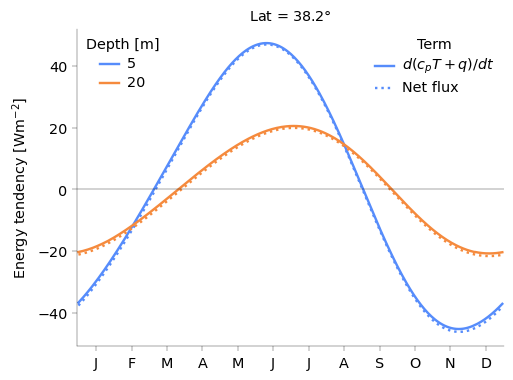

In [93]:
lat_plot_ind = 0
fig, ax = plt.subplots(1, 1, sharex=True)
fig_resize(fig, utils.width['two_col'])
for i in range(ds.depth.size):
    l1, = ax.plot(ds.time, ds.atmos_energy_tend.isel(lat=lat_plot_ind, depth=i), color=f"C{i}", label=f'{ds.depth[i]:.0f}')
    l2, = ax.plot(ds.time, ds.atmos_flux_net.isel(lat=lat_plot_ind, depth=i), color=f"C{i}", linestyle=':')
    if i == 0:
        style_handles = [l1, l2]
update_linewidth(fig)
# First legend: depth colors
leg1 = ax.legend(title='Depth [m]', loc='upper left')
ax.add_artist(leg1)

ax.legend(style_handles, ['$d(c_pT+q)/dt$', 'Net flux'], title='Term', loc='upper right')
ax.axhline(0, color='k', lw=ax_linewidth)
ax.set_xlim(-1, 360)
ax.set_xticks(*utils.month_ticks)
ax.set_ylabel('Energy tendency [Wm$^{-2}$]')
ax.set_title(f'Lat = {ds.lat[lat_plot_ind]:.1f}$\degree$')
update_fontsize(fig, 6)
plt.show()

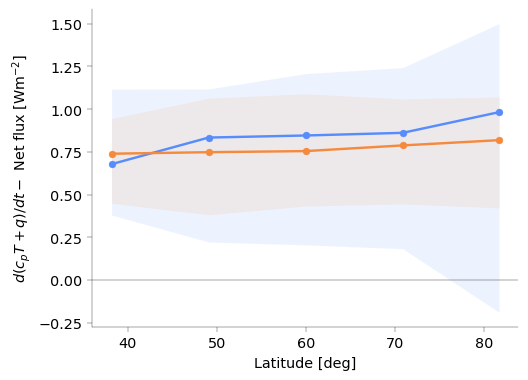

In [91]:
fig, ax = plt.subplots(1, 1, sharex=True)
fig_resize(fig, utils.width['two_col'])
for i in range(ds.depth.size):
    ax.plot(ds.lat, (ds_base.atmos_energy_tend - ds_base.atmos_flux_net).median(dim='time').isel(depth=i),
            color=f"C{i}", marker='.', markersize=10)
    ax.fill_between(ds.lat, (ds_base.atmos_energy_tend - ds_base.atmos_flux_net).isel(depth=i).quantile(0.1, dim='time').squeeze(),
                    (ds_base.atmos_energy_tend - ds_base.atmos_flux_net).isel(depth=i).quantile(0.9, dim='time').squeeze(),
                    color=f"C{i}", alpha=0.1, lw=0)
update_linewidth(fig)
ax.axhline(0, color='k', lw=ax_linewidth)
ax.set_xlabel(utils.label_lat)
ax.set_ylabel('$d(c_pT+q)/dt - $ Net flux [Wm$^{-2}$]')
update_fontsize(fig, 6)
plt.show()